#### Import Libraries

In [14]:
import os
import pandas as pd
import logging
from sqlalchemy import create_engine, text

#### Setup Logging for Transparency

In [15]:

# Setup Logging
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# db configs
db_path = r"C:\Algorthmic Trading for Beginners\Data Management\Database\options_data.db"
engine = create_engine(f"sqlite:///{db_path}")

#### Extract Data

In [16]:
# Define the SQL query to retrieve all data from 'call_options_data' table
query_call = "SELECT * FROM call_options_data"

# Define the SQL query to retrieve all data from 'put_options_data' table
query_put = "SELECT * FROM put_options_data"

# Execute query and load data into a DF
call_data_completed = pd.read_sql(query_call, con=engine)
put_data_completed = pd.read_sql(query_put, con=engine)

call_data_completed.head()

,id,quote_date,symbol,underlying_last,expire_date,expiry_type,dte,strike,strike_distance,strike_distance_pct,...,c_theta,c_rho,c_iv,c_volume,c_last,c_size,c_bid,c_ask,c_mid,c_spread
0,1,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4250.0,-58.27,-0.014,...,-4.11692,2.18091,0.54668,207.0,2161.30,9 x 6,2024.71,2307.11,2165.910,282.40
1,2,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4255.0,-53.27,-0.012,...,-3.69690,1.99935,0.49091,198.0,2160.31,3 x 20,2022.42,2307.61,2165.015,285.19
2,3,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4260.0,-48.27,-0.011,...,-3.31453,1.81650,0.44013,201.0,2159.39,1 x 18,2020.18,2308.18,2164.180,288.00
3,4,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4265.0,-43.27,-0.010,...,-2.96982,1.63243,0.39436,196.0,2158.53,3 x 12,2018.01,2308.84,2163.425,290.83
4,5,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4270.0,-38.27,-0.009,...,-2.66276,1.44722,0.35359,218.0,2157.75,6 x 4,2015.90,2309.57,2162.735,293.67


In [17]:
put_data_completed.head()

,id,quote_date,symbol,underlying_last,expire_date,expiry_type,dte,strike,strike_distance,strike_distance_pct,...,p_theta,p_rho,p_iv,p_volume,p_last,p_size,p_bid,p_ask,p_mid,p_spread
0,1,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4250.0,-58.27,-0.014,...,-4.23265,0.0,0.58064,205.0,2077.43,3 x 7,1915.47,2253.08,2084.275,337.61
1,2,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4255.0,-53.27,-0.012,...,-3.81277,0.0,0.51929,169.0,2081.41,3 x 6,1920.42,2255.89,2088.155,335.47
2,3,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4260.0,-48.27,-0.011,...,-3.43054,0.0,0.46344,216.0,2085.45,1 x 17,1925.43,2258.77,2092.100,333.34
3,4,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4265.0,-43.27,-0.010,...,-3.08596,0.0,0.41309,199.0,2089.57,10 x 7,1930.53,2261.71,2096.120,331.18
4,5,2023-10-03,SPX,4308.27,2023-10-03,Daily,0.6,4270.0,-38.27,-0.009,...,-2.77904,0.0,0.36823,161.0,2093.75,9 x 19,1935.70,2264.71,2100.205,329.01


#### Extract Data for a Specific Date

In [18]:
# Date for filtering options data
date = "2023-10-03"

# SQL query with a parameterised filter for a specific quote_date
query_date_call = text("SELECT * FROM call_options_data WHERE quote_date = :date")
query_date_put = text("SELECT * FROM put_options_data WHERE quote_date = :date")

# Execute the parameterised query and load data into a DF
call_data_specific_date = pd.read_sql(query_date_call, con=engine, params={"date": date})
put_data_specific_date = pd.read_sql(query_date_put, con=engine, params={"date": date})

print(call_data_specific_date.head())
print(put_data_specific_date.head())

   id  quote_date symbol  underlying_last expire_date expiry_type  dte  \
0   1  2023-10-03    SPX          4308.27  2023-10-03       Daily  0.6   
1   2  2023-10-03    SPX          4308.27  2023-10-03       Daily  0.6   
2   3  2023-10-03    SPX          4308.27  2023-10-03       Daily  0.6   
3   4  2023-10-03    SPX          4308.27  2023-10-03       Daily  0.6   
4   5  2023-10-03    SPX          4308.27  2023-10-03       Daily  0.6   

   strike  strike_distance  strike_distance_pct  ...  c_theta    c_rho  \
0  4250.0           -58.27               -0.014  ... -4.11692  2.18091   
1  4255.0           -53.27               -0.012  ... -3.69690  1.99935   
2  4260.0           -48.27               -0.011  ... -3.31453  1.81650   
3  4265.0           -43.27               -0.010  ... -2.96982  1.63243   
4  4270.0           -38.27               -0.009  ... -2.66276  1.44722   

      c_iv  c_volume   c_last  c_size    c_bid    c_ask     c_mid  c_spread  
0  0.54668     207.0  2161.30   

#### Extract Data for Gamma Scalping 

In [28]:
call_data_completed.describe().round(1)


,id,underlying_last,dte,strike,strike_distance,strike_distance_pct,c_delta,c_gamma,c_vega,c_theta,c_rho,c_iv,c_volume,c_last,c_bid,c_ask,c_mid,c_spread
count,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0
mean,18964.0,4312.5,7.7,4300.0,-12.5,-0.0,0.5,0.0,102.6,-2.4,4.9,0.9,56.0,2160.4,1988.0,2348.0,2168.0,360.0
std,10948.7,8.6,7.6,83.9,84.4,0.0,0.0,0.0,61.5,1.5,8.6,1.1,48.5,16.2,30.7,32.9,16.2,54.8
min,1.0,4291.0,0.3,4100.0,-229.7,-0.1,0.4,0.0,25.2,-7.8,0.0,0.2,2.0,2114.3,1902.0,2295.1,2126.2,263.9
25%,9482.5,4306.4,2.4,4250.0,-64.2,-0.0,0.5,0.0,66.5,-3.2,0.0,0.3,19.0,2152.2,1975.7,2325.4,2159.2,316.6
50%,18964.0,4312.3,3.4,4300.0,-12.4,-0.0,0.5,0.0,79.9,-2.0,0.7,0.5,34.0,2158.4,1994.8,2333.7,2165.0,339.1
75%,28445.5,4318.8,17.5,4350.0,39.5,0.0,0.5,0.0,180.5,-1.1,5.9,1.1,91.0,2166.8,2009.4,2372.3,2173.3,424.6
max,37927.0,4329.7,18.6,4500.0,209.0,0.0,0.6,0.0,186.2,-0.3,38.6,5.5,223.0,2221.3,2049.3,2442.6,2231.3,448.7


In [29]:
put_data_completed.describe().round(1)

,id,underlying_last,dte,strike,strike_distance,strike_distance_pct,p_delta,p_gamma,p_vega,p_theta,p_rho,p_iv,p_volume,p_last,p_bid,p_ask,p_mid,p_spread
count,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0,37927.0
mean,18964.0,4312.5,7.7,4300.0,-12.5,-0.0,-0.5,0.0,102.6,-2.5,-3.8,1.0,56.0,1841.2,1694.6,2000.8,1847.7,306.2
std,10948.7,8.6,7.6,83.9,84.4,0.0,0.0,0.0,61.5,1.5,7.9,1.2,48.3,302.0,295.3,307.7,301.4,16.4
min,1.0,4291.0,0.3,4100.0,-229.7,-0.1,-0.6,0.0,25.2,-7.9,-39.1,0.2,2.0,1299.2,1168.5,1444.6,1306.6,272.9
25%,9482.5,4306.4,2.4,4250.0,-64.2,-0.0,-0.5,0.0,66.5,-3.4,-3.6,0.3,19.0,1500.1,1360.2,1654.5,1507.3,292.9
50%,18964.0,4312.3,3.4,4300.0,-12.4,-0.0,-0.5,0.0,79.9,-2.1,0.0,0.5,34.0,1992.0,1839.0,2157.5,1998.4,306.8
75%,28445.5,4318.8,17.5,4350.0,39.5,0.0,-0.5,0.0,180.5,-1.2,0.0,1.2,91.0,2089.9,1934.7,2259.6,2096.2,318.2
max,37927.0,4329.7,18.6,4500.0,209.0,0.0,-0.4,0.0,186.2,-0.4,0.0,6.0,225.0,2195.0,2062.7,2335.6,2199.2,355.0


In [51]:
call_gamma_scalp_query = """
SELECT * 
FROM call_options_data
WHERE symbol = :symbol
  AND ABS(strike_distance) <= 15
  AND quote_date = :date
  AND c_gamma >= 0.0004
  AND c_iv >= 0.50
  AND dte <= 3
ORDER BY expire_date, strike;
"""

put_gamma_scalp_query = """
SELECT * 
FROM put_options_data
WHERE symbol = :symbol
  AND ABS(strike_distance) <= 20
  AND quote_date = :date
  AND p_gamma >= 0.0003
  AND p_iv >= 0.50
  AND dte <= 4
ORDER BY expire_date, strike;
"""

call_scalp_data = pd.read_sql(call_gamma_scalp_query, con=engine, params={"symbol": "SPX", "date": date})
put_scalp_data = pd.read_sql(put_gamma_scalp_query, con=engine, params={"symbol": "SPX", "date": date})

call_scalp_data.head()

,id,quote_date,symbol,underlying_last,expire_date,expiry_type,dte,strike,strike_distance,strike_distance_pct,...,c_theta,c_rho,c_iv,c_volume,c_last,c_size,c_bid,c_ask,c_mid,c_spread


In [52]:
put_scalp_data.head()

,id,quote_date,symbol,underlying_last,expire_date,expiry_type,dte,strike,strike_distance,strike_distance_pct,...,p_theta,p_rho,p_iv,p_volume,p_last,p_size,p_bid,p_ask,p_mid,p_spread


- SPX is not suitable for Gamma Scalping

#### Extract Data for IV Crush

In [69]:
call_crush_query = """
SELECT *
FROM call_options_data
WHERE symbol = :symbol
  AND quote_date = :date
  AND c_iv >= 0.7
  AND c_volume >= 20
ORDER BY expire_date, strike;
"""



put_crush_query = """
SELECT *
FROM put_options_data
WHERE symbol = :symbol
  AND quote_date = :date
  AND p_iv >= 0.7
  AND p_volume >= 20
ORDER BY expire_date, strike;
"""

call_crush_data = pd.read_sql(call_crush_query, con=engine, params={"symbol": "SPX", "date": date})
put_crush_data = pd.read_sql(put_crush_query, con=engine, params={"symbol": "SPX", "date": date})

call_crush_data.head()

,id,quote_date,symbol,underlying_last,expire_date,expiry_type,dte,strike,strike_distance,strike_distance_pct,...,c_theta,c_rho,c_iv,c_volume,c_last,c_size,c_bid,c_ask,c_mid,c_spread
0,4957,2023-10-03,SPX,4322.33,2023-10-03,Daily,0.55,4250.0,-72.33,-0.017,...,-5.79692,2.54667,0.72992,123.0,2171.70,10 x 2,2039.40,2312.58,2175.990,273.18
1,5488,2023-10-03,SPX,4323.39,2023-10-03,Daily,0.54,4250.0,-73.39,-0.017,...,-5.95466,2.56680,0.74537,106.0,2172.53,8 x 8,2040.61,2312.97,2176.790,272.36
2,5665,2023-10-03,SPX,4321.55,2023-10-03,Daily,0.54,4250.0,-71.55,-0.017,...,-5.74920,2.50035,0.71859,89.0,2171.15,6 x 12,2038.85,2312.04,2175.445,273.19
3,6078,2023-10-03,SPX,4324.27,2023-10-03,Daily,0.53,4250.0,-74.27,-0.017,...,-6.09747,2.57839,0.75825,88.0,2173.22,3 x 6,2041.67,2313.26,2177.465,271.59
4,6432,2023-10-03,SPX,4321.00,2023-10-03,Daily,0.53,4250.0,-71.00,-0.016,...,-5.73358,2.46053,0.71080,81.0,2170.79,3 x 3,2038.55,2311.60,2175.075,273.05


In [70]:
put_crush_data.head()

,id,quote_date,symbol,underlying_last,expire_date,expiry_type,dte,strike,strike_distance,strike_distance_pct,...,p_theta,p_rho,p_iv,p_volume,p_last,p_size,p_bid,p_ask,p_mid,p_spread
0,3128,2023-10-03,SPX,4317.94,2023-10-03,Daily,0.57,4250.0,-67.94,-0.016,...,-5.31984,0.0,0.71468,178.0,2076.37,9 x 19,1911.68,2255.26,2083.470,343.58
1,3600,2023-10-03,SPX,4319.09,2023-10-03,Daily,0.56,4250.0,-69.09,-0.016,...,-5.46901,0.0,0.73191,154.0,2076.33,3 x 7,1911.27,2255.64,2083.455,344.37
2,3954,2023-10-03,SPX,4317.54,2023-10-03,Daily,0.56,4250.0,-67.54,-0.016,...,-5.32007,0.0,0.70857,152.0,2076.93,5 x 3,1912.17,2255.88,2084.025,343.71
3,4190,2023-10-03,SPX,4318.46,2023-10-03,Daily,0.55,4250.0,-68.46,-0.016,...,-5.43292,0.0,0.72240,160.0,2076.81,5 x 2,1911.79,2256.08,2083.935,344.29
4,4426,2023-10-03,SPX,4318.78,2023-10-03,Daily,0.55,4250.0,-68.78,-0.016,...,-5.48086,0.0,0.72720,151.0,2076.86,2 x 13,1911.71,2256.26,2083.985,344.55


#### Data visualization of Crush Data

In [72]:
# Basic Statistics
call_crush_data.describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
id,105.0,11343.86,3000.91,4957.00,8970.00,11094.00,13690.00,17996.00
underlying_last,105.0,4324.92,2.83,4320.32,4322.42,4325.16,4327.25,4329.58
dte,105.0,0.47,0.04,0.39,0.44,0.47,0.50,0.55
strike,105.0,4251.24,2.17,4250.00,4250.00,4250.00,4250.00,4255.00
strike_distance,105.0,-73.68,2.55,-79.58,-75.16,-73.21,-71.55,-70.32
strike_distance_pct,105.0,-0.02,0.00,-0.02,-0.02,-0.02,-0.02,-0.02
c_delta,105.0,0.62,0.01,0.61,0.62,0.62,0.62,0.63
c_gamma,105.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
c_vega,105.0,29.96,1.11,27.42,29.14,30.08,30.86,32.22
c_theta,105.0,-6.42,0.42,-7.30,-6.70,-6.42,-6.08,-5.68


In [73]:
put_crush_data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
id,196.0,11428.18,3619.24,3128.00,8880.75,11152.50,13881.50,19766.00
underlying_last,196.0,4323.50,3.62,4317.12,4320.41,4323.65,4326.65,4329.58
dte,196.0,0.47,0.04,0.37,0.44,0.47,0.50,0.57
strike,196.0,4252.22,3.17,4250.00,4250.00,4250.00,4255.00,4260.00
strike_distance,196.0,-71.28,3.24,-79.58,-73.32,-70.52,-68.68,-67.07
strike_distance_pct,196.0,-0.02,0.00,-0.02,-0.02,-0.02,-0.02,-0.02
p_delta,196.0,-0.38,0.01,-0.40,-0.39,-0.38,-0.38,-0.37
p_gamma,196.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
p_vega,196.0,29.91,1.33,26.67,29.03,30.06,30.88,32.81
p_theta,196.0,-6.25,0.49,-7.41,-6.61,-6.18,-5.89,-5.32


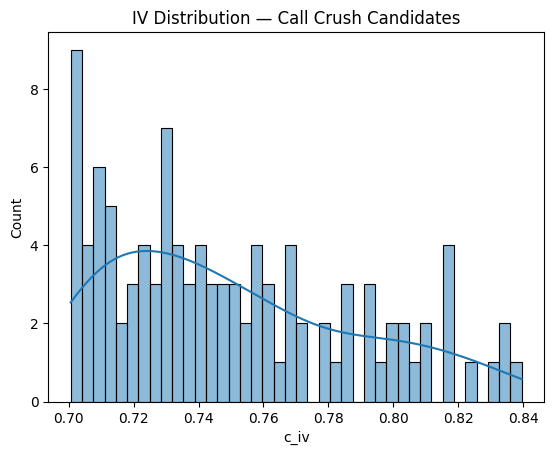

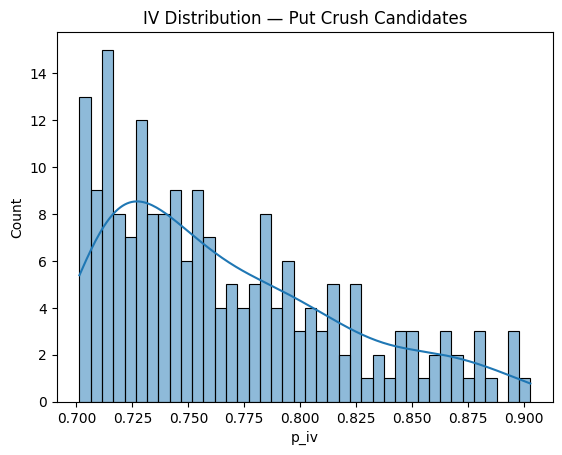

In [75]:
# IV Distribution Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(call_crush_data['c_iv'], bins=40, kde=True)
plt.title("IV Distribution — Call Crush Candidates")
plt.show()

sns.histplot(put_crush_data['p_iv'], bins=40, kde=True)
plt.title("IV Distribution — Put Crush Candidates")
plt.show()

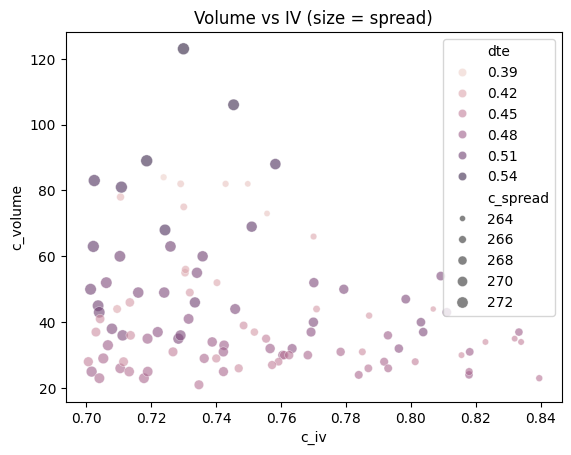

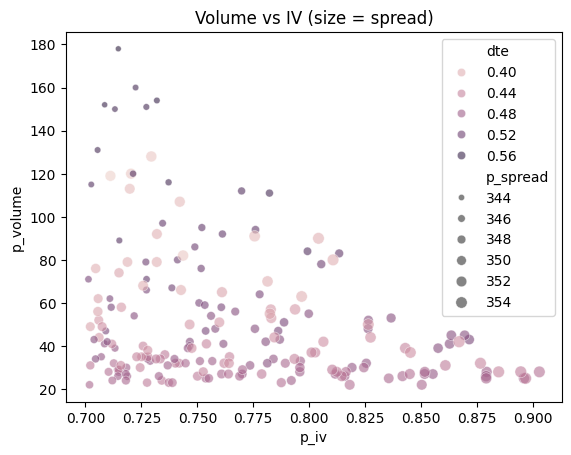

In [76]:
# Vol vs IV (Liquidity vs Opportunity)
sns.scatterplot(
    data=call_crush_data,
    x='c_iv',
    y='c_volume',
    hue='dte',
    size='c_spread',
    alpha=0.6
)
plt.title("Volume vs IV (size = spread)")
plt.show()

sns.scatterplot(
    data=put_crush_data,
    x='p_iv',
    y='p_volume',
    hue='dte',
    size='p_spread',
    alpha=0.6
)
plt.title("Volume vs IV (size = spread)")
plt.show()

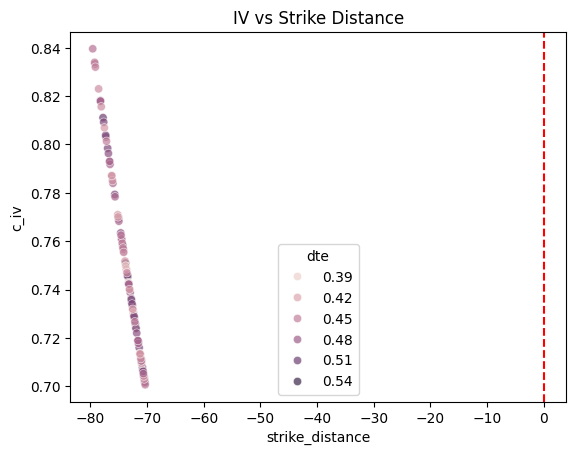

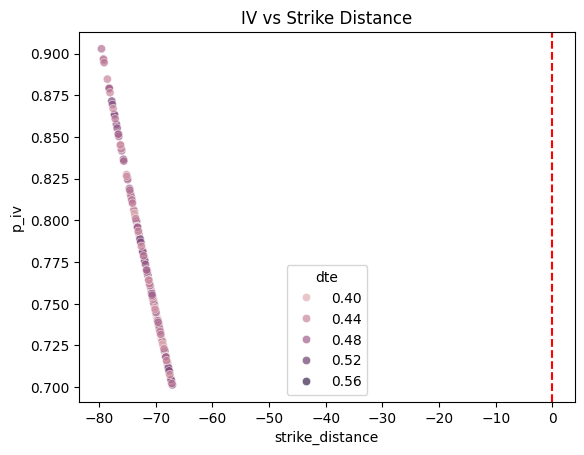

In [77]:
# IV vs Strike Distance (OTM vs ATM)
sns.scatterplot(
    data=call_crush_data,
    x='strike_distance',
    y='c_iv',
    hue='dte',
    alpha=0.7
)
plt.axvline(0, color='red', linestyle='--')
plt.title("IV vs Strike Distance")
plt.show()


sns.scatterplot(
    data=put_crush_data,
    x='strike_distance',
    y='p_iv',
    hue='dte',
    alpha=0.7
)
plt.axvline(0, color='red', linestyle='--')
plt.title("IV vs Strike Distance")
plt.show()

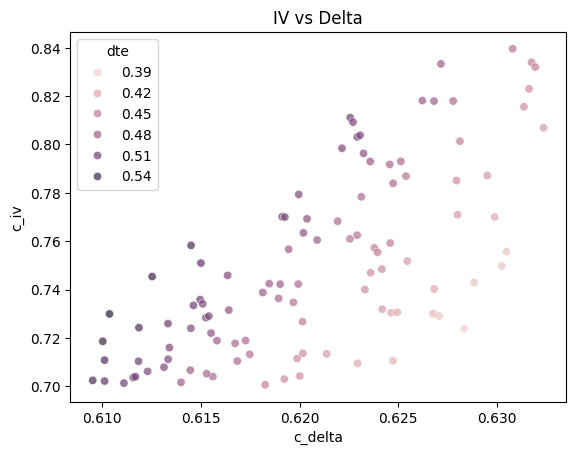

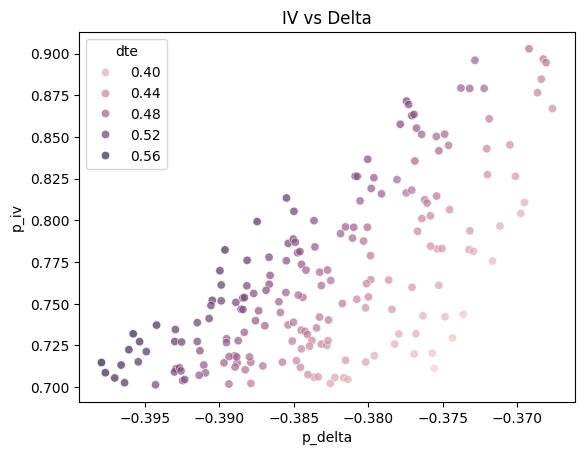

In [78]:
# IV vs Delta (Risk Profile)
sns.scatterplot(
    data=call_crush_data,
    x='c_delta',
    y='c_iv',
    hue='dte',
    alpha=0.7
)
plt.title("IV vs Delta")
plt.show()


sns.scatterplot(
    data=put_crush_data,
    x='p_delta',
    y='p_iv',
    hue='dte',
    alpha=0.7
)  
plt.title("IV vs Delta")
plt.show()

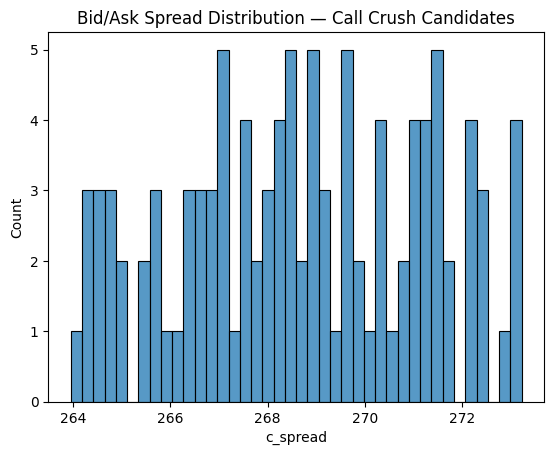

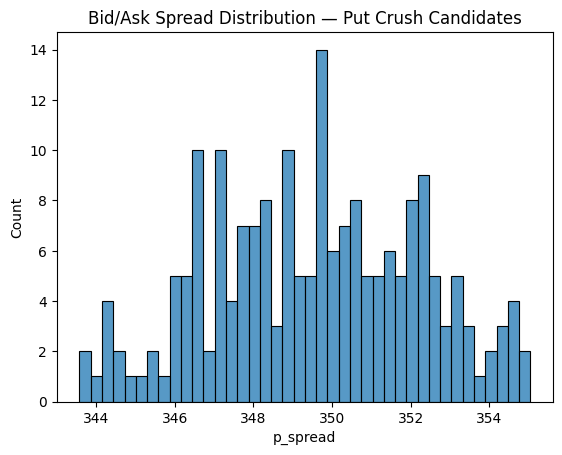

In [80]:
# Spread Diagnostics (Tradeability)
sns.histplot(call_crush_data['c_spread'], bins=40)
plt.title("Bid/Ask Spread Distribution — Call Crush Candidates")
plt.show()


sns.histplot(put_crush_data['p_spread'], bins=40)
plt.title("Bid/Ask Spread Distribution — Put Crush Candidates") 
plt.show()

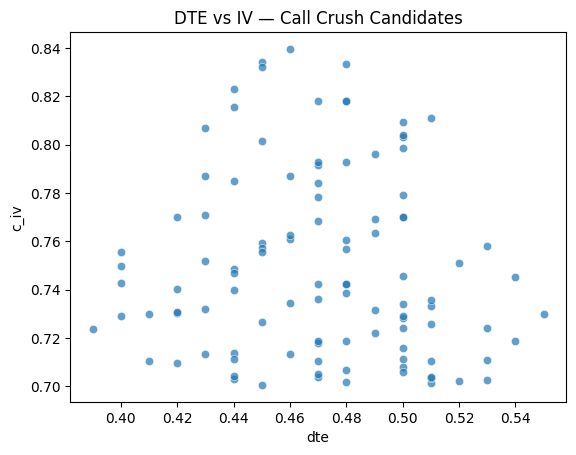

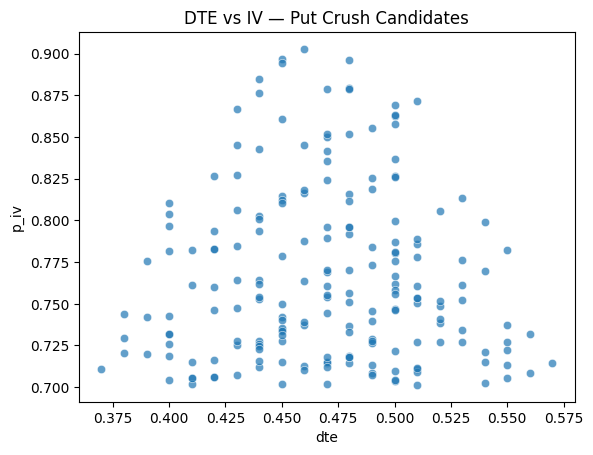

In [81]:
# DTE vs IV (Term Structure)
sns.scatterplot(
    data=call_crush_data,
    x='dte',
    y='c_iv',
    alpha=0.7
)
plt.title("DTE vs IV — Call Crush Candidates")
plt.show()


sns.scatterplot(
    data=put_crush_data,
    x='dte',
    y='p_iv',
    alpha=0.7
)
plt.title("DTE vs IV — Put Crush Candidates")
plt.show()

In [82]:
# Combined IV Crush Score (Ranking)
call_crush_data['crush_score'] = (
    call_crush_data['c_iv'] * 0.6 +
    call_crush_data['c_volume'].rank(pct=True) * 0.3 -
    call_crush_data['c_spread'].rank(pct=True) * 0.1
)

call_crush_data.sort_values('crush_score', ascending=False).head(10)

put_crush_data['crush_score'] = (
    put_crush_data['p_iv'] * 0.6 +
    put_crush_data['p_volume'].rank(pct=True) * 0.3 -
    put_crush_data['p_spread'].rank(pct=True) * 0.1
)

put_crush_data.sort_values('crush_score', ascending=False).head(10)

,id,quote_date,symbol,underlying_last,expire_date,expiry_type,dte,strike,strike_distance,strike_distance_pct,...,p_rho,p_iv,p_volume,p_last,p_size,p_bid,p_ask,p_mid,p_spread,crush_score
1,3600,2023-10-03,SPX,4319.09,2023-10-03,Daily,0.56,4250.0,-69.09,-0.016,...,0.0,0.73191,154.0,2076.33,3 x 7,1911.27,2255.64,2083.455,344.37,0.733024
7,4957,2023-10-03,SPX,4322.33,2023-10-03,Daily,0.55,4250.0,-72.33,-0.017,...,0.0,0.78224,111.0,2076.24,6 x 2,1910.15,2256.76,2083.455,346.61,0.731079
3,4190,2023-10-03,SPX,4318.46,2023-10-03,Daily,0.55,4250.0,-68.46,-0.016,...,0.0,0.72240,160.0,2076.81,5 x 2,1911.79,2256.08,2083.935,344.29,0.729358
0,3128,2023-10-03,SPX,4317.94,2023-10-03,Daily,0.57,4250.0,-67.94,-0.016,...,0.0,0.71468,178.0,2076.37,9 x 19,1911.68,2255.26,2083.470,343.58,0.728298
10,5665,2023-10-03,SPX,4321.55,2023-10-03,Daily,0.54,4250.0,-71.55,-0.017,...,0.0,0.76978,112.0,2076.82,6 x 18,1910.78,2257.30,2084.040,346.52,0.727174
4,4426,2023-10-03,SPX,4318.78,2023-10-03,Daily,0.55,4250.0,-68.78,-0.016,...,0.0,0.72720,151.0,2076.86,2 x 13,1911.71,2256.26,2083.985,344.55,0.726116
6,4603,2023-10-03,SPX,4319.44,2023-10-03,Daily,0.55,4250.0,-69.44,-0.016,...,0.0,0.73714,116.0,2076.78,5 x 13,1911.45,2256.41,2083.930,344.96,0.720345
2,3954,2023-10-03,SPX,4317.54,2023-10-03,Daily,0.56,4250.0,-67.54,-0.016,...,0.0,0.70857,152.0,2076.93,5 x 3,1912.17,2255.88,2084.025,343.71,0.719530
5,4544,2023-10-03,SPX,4317.85,2023-10-03,Daily,0.55,4250.0,-67.85,-0.016,...,0.0,0.71316,150.0,2077.17,10 x 5,1912.22,2256.34,2084.280,344.12,0.718712
9,5488,2023-10-03,SPX,4323.39,2023-10-03,Daily,0.54,4250.0,-73.39,-0.017,...,0.0,0.79924,84.0,2076.27,6 x 4,1909.82,2257.22,2083.520,347.40,0.715768


#### Interpretation of IV Crush Strategy for SPX Options

- IV‑Crush is NOT the right strategy for SPX because:

1) SPX has no earnings‑style catalysts
2) IV is extremely stable (0.70–0.85)
3) dataset is dominated by 0DTE options
4) Deep OTM skew drives IV, not event risk
5) Bid/ask spreads are too wide
6) Volume vs IV shows no exploitable mispricing
7) SPX is institutionally hedged and highly efficient